<a href="https://colab.research.google.com/github/pevu97/MIssles-and-Rocket-Identification/blob/main/missile_rocket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import TensorBoard


In [2]:
!wget https://storage.googleapis.com/esmartdata-courses-files/ann-course/flying-vehicles.zip
!unzip -q flying-vehicles.zip

--2026-03-06 13:05:58--  https://storage.googleapis.com/esmartdata-courses-files/ann-course/flying-vehicles.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.20.207, 108.177.98.207, 74.125.135.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.20.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1540232238 (1.4G) [application/x-zip-compressed]
Saving to: ‘flying-vehicles.zip’

flying-vehicles.zip 100%[===================>]   1.43G  24.6MB/s    in 61s     

2026-03-06 13:07:00 (24.1 MB/s) - ‘flying-vehicles.zip’ saved [1540232238/1540232238]



In [3]:
!rm -rf ./images

In [4]:
base_dir = './data/planes'
raw_no_of_files = {}
classes = ['drone', 'fighter-jet', 'helicopter', 'missile', 'passenger-plane', 'rocket']
for dir in classes:
  raw_no_of_files[dir] = len(os.listdir(os.path.join(base_dir, dir)))

raw_no_of_files.items()

dict_items([('drone', 1332), ('fighter-jet', 1867), ('helicopter', 1387), ('missile', 1334), ('passenger-plane', 1424), ('rocket', 1186)])

In [5]:
data_dir = './images'

if not os.path.exists(data_dir):
  os.mkdir(data_dir)

train_dir = os.path.join(data_dir, 'train')
valid_dir = os.path.join(data_dir, 'valid')
test_dir = os.path.join(data_dir, 'test')

for directory in (train_dir, valid_dir, test_dir):
  if not os.path.exists(directory):
    os.mkdir(directory)

train_missile_dir = os.path.join(train_dir, 'missile')
train_rocket_dir = os.path.join(train_dir, 'rocket')

valid_missile_dir = os.path.join(valid_dir, 'missile')
valid_rocket_dir = os.path.join(valid_dir, 'rocket')

test_missile_dir = os.path.join(test_dir, 'missile')
test_rocket_dir = os.path.join(test_dir, 'rocket')

dirs = [train_missile_dir, train_rocket_dir, valid_missile_dir, valid_rocket_dir, test_missile_dir, test_rocket_dir]

for dir in dirs:
  if not os.path.exists(dir):
    os.mkdir(dir)

In [6]:
missile_fnames = os.listdir(os.path.join(base_dir, 'missile'))
rocket_fnames = os.listdir(os.path.join(base_dir, 'rocket'))


In [7]:
missile_fnames = [fname for fname in missile_fnames if fname.split('.')[1].lower() in ['jpg', 'png', 'jpeg']]
rocket_fnames = [fname for fname in rocket_fnames if fname.split('.')[1].lower() in ['jpg', 'png', 'jpeg']]


In [8]:
size = min(len(missile_fnames), len(rocket_fnames))
size

1173

In [9]:
train_size = int(np.floor(0.7 * size))
valid_size = int(np.floor(0.2 * size))
test_size = size - train_size - valid_size

train_size, valid_size, test_size

train_idx = train_size
valid_idx = train_size + valid_size
test_idx = train_size + valid_size + test_size

In [10]:

for i, fname in enumerate(missile_fnames):
    if i <= train_idx:
        src = os.path.join(base_dir, 'missile', fname)
        dst = os.path.join(train_missile_dir, fname)
        shutil.copyfile(src, dst)
    elif train_idx < i <= valid_idx:
        src = os.path.join(base_dir, 'missile', fname)
        dst = os.path.join(valid_missile_dir, fname)
        shutil.copyfile(src, dst)
    elif valid_idx < i < test_idx:
        src = os.path.join(base_dir, 'missile', fname)
        dst = os.path.join(test_missile_dir, fname)
        shutil.copyfile(src, dst)

for i, fname in enumerate(rocket_fnames):
    if i <= train_idx:
        src = os.path.join(base_dir, 'rocket', fname)
        dst = os.path.join(train_rocket_dir, fname)
        shutil.copyfile(src, dst)
    elif train_idx < i <= valid_idx:
        src = os.path.join(base_dir, 'rocket', fname)
        dst = os.path.join(valid_rocket_dir, fname)
        shutil.copyfile(src, dst)
    elif valid_idx < i < test_idx:
        src = os.path.join(base_dir, 'rocket', fname)
        dst = os.path.join(test_rocket_dir, fname)
        shutil.copyfile(src, dst)

print('missile - zbiór treningowy', len(os.listdir(train_missile_dir)))
print('missile - zbiór walidacyjny', len(os.listdir(valid_missile_dir)))
print('missile - zbiór testowy', len(os.listdir(test_missile_dir)))

print('rocket - zbiór treningowy', len(os.listdir(train_rocket_dir)))
print('rocket - zbiór testowy', len(os.listdir(test_rocket_dir)))

missile - zbiór treningowy 822
missile - zbiór walidacyjny 234
missile - zbiór testowy 117
rocket - zbiór treningowy 822
rocket - zbiór testowy 117


In [11]:
type(train_size)

int

In [12]:
train_size

821

(np.float64(-0.5), np.float64(299.5), np.float64(179.5), np.float64(-0.5))

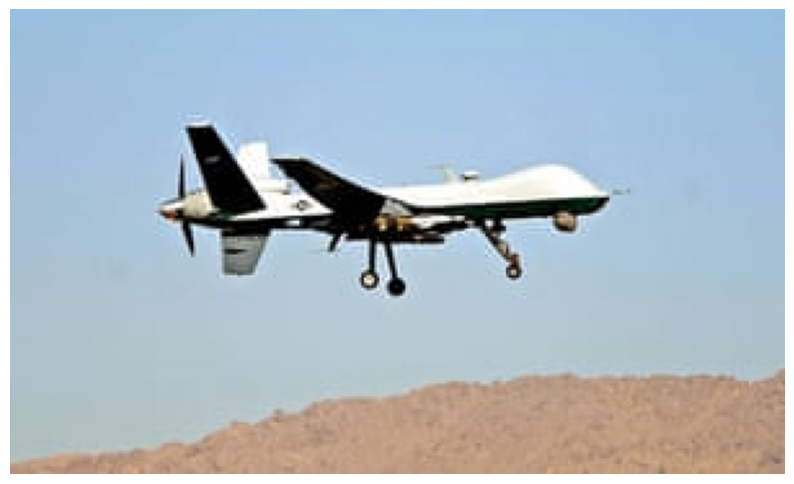

In [13]:
idx = 81 #@param {type: 'slider', min:0, max:821}
names_mapping = dict(enumerate(missile_fnames))
img_path = os.path.join(train_missile_dir, names_mapping[idx])

img = image.load_img(img_path)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.grid(False)
plt.axis(False)

(np.float64(-0.5), np.float64(819.5), np.float64(546.5), np.float64(-0.5))

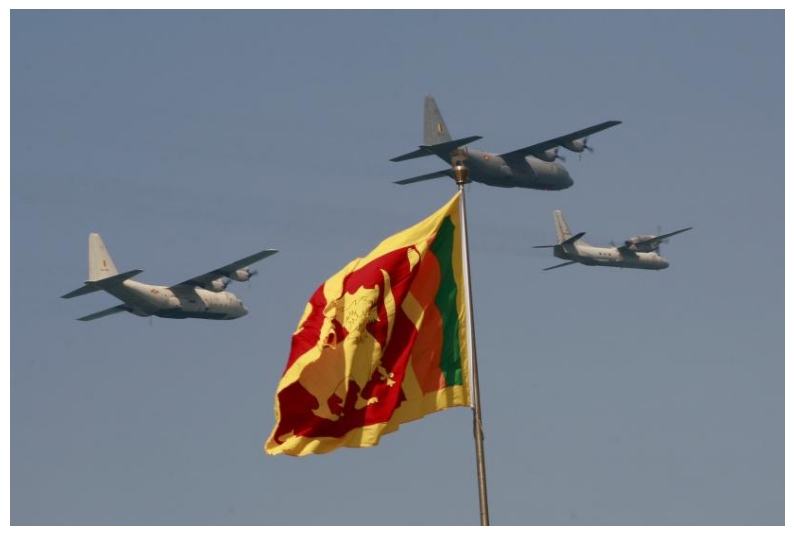

In [14]:
idx = 349 #@param {type: 'slider', min:0, max:821}
names_mapping = dict(enumerate(rocket_fnames))
img_path = os.path.join(train_rocket_dir, names_mapping[idx])

img = image.load_img(img_path)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.grid(False)
plt.axis(False)

In [15]:
train_datagen = ImageDataGenerator(
    rotation_range=40,
    rescale=1./255.,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255.)

train_generator = train_datagen.flow_from_directory(directory=train_dir,
                                                    target_size=(150, 150),
                                                    batch_size=32,
                                                    class_mode='binary')

valid_generator = valid_datagen.flow_from_directory(directory=valid_dir,
                                                    target_size=(150, 150),
                                                    batch_size=32,
                                                    class_mode='binary')


Found 1644 images belonging to 2 classes.
Found 468 images belonging to 2 classes.


In [16]:
def display_augmented_images(directory, idx):
  fnames = [os.path.join(directory, fname) for fname in os.listdir(directory)]
  img_path = fnames[idx]
  img = image.load_img(img_path, target_size=(150, 150))

  x = image.img_to_array(img)
  x = x.reshape((1, ) + x.shape)

  i = 1
  plt.figure(figsize=(16, 8))
  for batch in train_datagen.flow(x, batch_size = 1):
    plt.subplot(3, 4, i)
    plt.grid(False)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 13 ==0:
      break

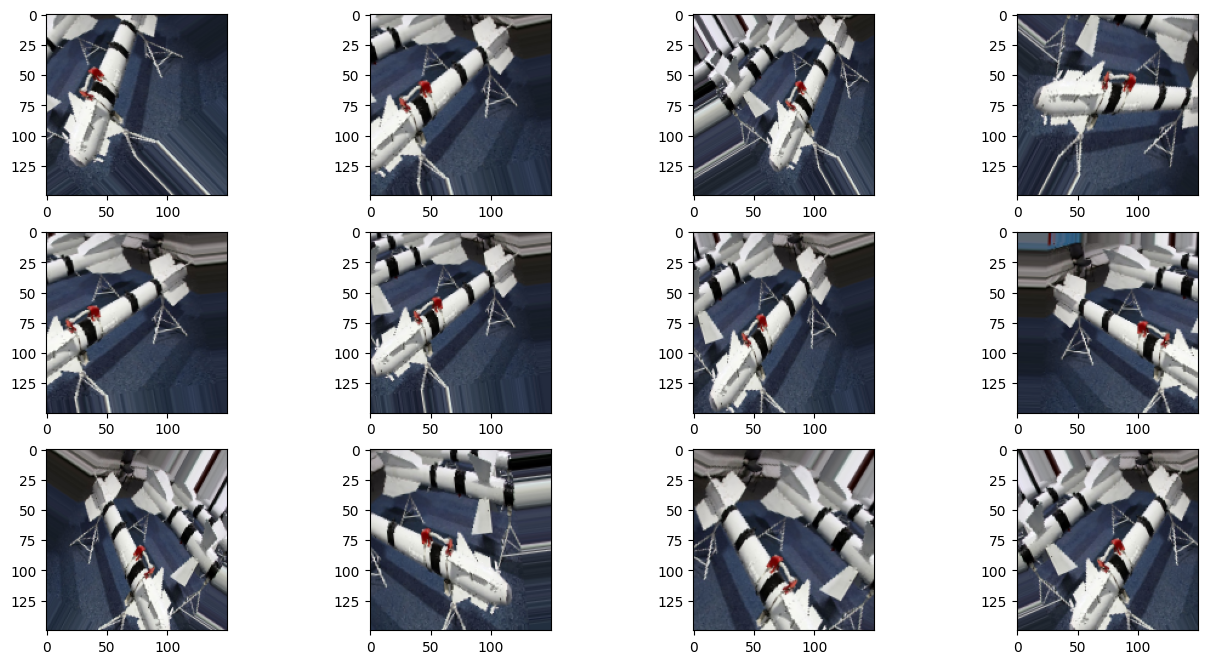

In [22]:
#@title Zbiór treningowy Missiles:
idx = 467 #@param {type:'slider', min:0, max:919}
display_augmented_images(train_missile_dir, idx)

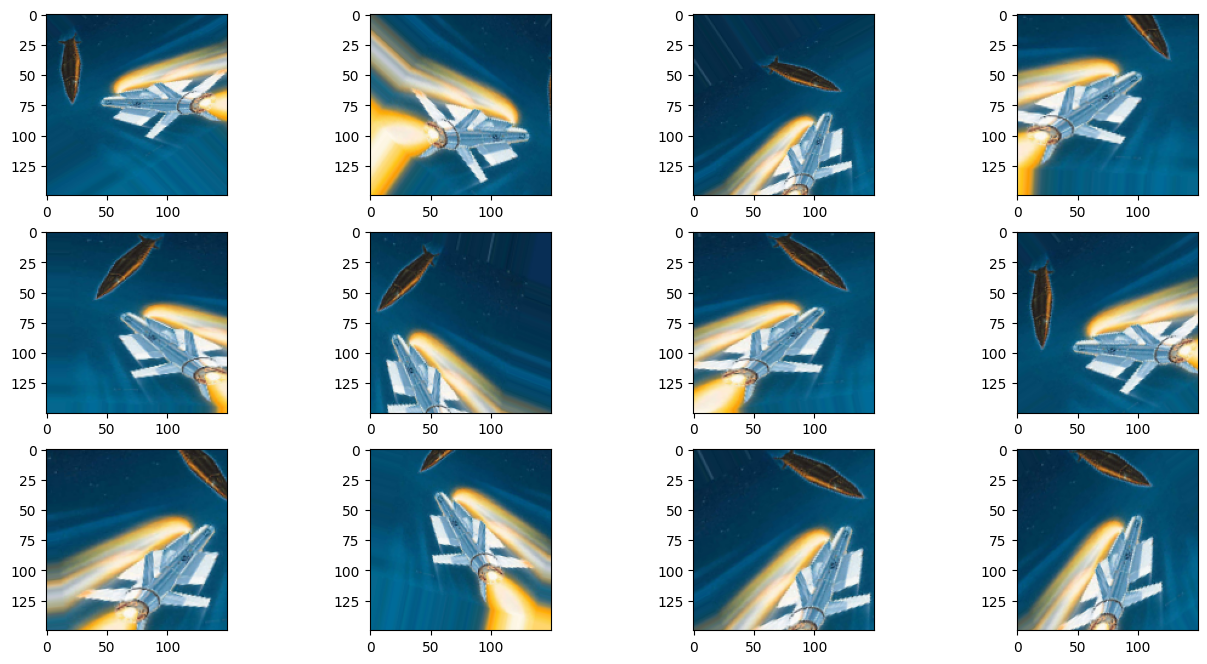

In [23]:
#@title Zbiór treningowy Rocket:
idx = 500 #@param {type:'slider', min:0, max:919}
display_augmented_images(train_missile_dir, idx)

In [24]:
model = Sequential()
model.add(layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size = (2, 2)))
model.add(layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D(pool_size = (2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(units=512, activation='relu'))
model.add(layers.Dense(units=1, activation='sigmoid'))

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    21,234,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,327,937 (81.36 MB)

 Trainable params: 21,327,937 (81.36 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(optimizer=optimizers.RMSprop(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [30]:
!rm -rf logs
!mkdir logs

tensorboard = TensorBoard(log_dir='logs')

In [34]:
batch_size = 32
steps_per_epoch = train_size // batch_size
validation_steps = valid_size // batch_size

history = model.fit(train_generator,
                    steps_per_epoch=steps_per_epoch,
                    epochs=30,
                    validation_data = valid_generator,
                    validation_steps = validation_steps,
                    callbacks=[tensorboard])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.4996 - loss: 0.7260 - val_accuracy: 0.5491 - val_loss: 0.6912
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.5109 - loss: 0.6955 - val_accuracy: 0.5670 - val_loss: 0.6845
Epoch 3/30
 2/25 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.5547 - loss: 0.6972

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 299ms/step - accuracy: 0.5188 - loss: 0.6993 - val_accuracy: 0.5223 - val_loss: 0.6892
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.5073 - loss: 0.6920 - val_accuracy: 0.5223 - val_loss: 0.6844
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - accuracy: 0.5314 - loss: 0.6906 - val_accuracy: 0.5089 - val_loss: 0.6841
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 334ms/step - accuracy: 0.3155 - loss: 0.7330 - val_accuracy: 0.5759 - val_loss: 0.6835
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.5449 - loss: 0.6860 - val_accuracy: 0.5982 - val_loss: 0.6776
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.5914 - loss: 0.6804 - val_accuracy: 0.5938 - val_loss: 0.6806
Epoch 9/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 298ms/step - accuracy: 0.5705 - loss: 0.7032 - val_accuracy: 0.5714 - val_loss: 0.6782
Epoch 10/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.5533 - loss: 0.6852 - val_accuracy: 0.5491 - val_loss: 0